<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
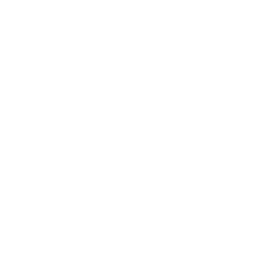
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Skuteczność wizyt promocyjnych przedstawicieli handlowych z wyborem opóźnień</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Analityka farmaceutyczna / komercyjna &nbsp;|&nbsp; marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie wykonawcze

Ocena wpływu wizyt promocyjnych u lekarzy (detailing) oraz dystrybucji próbek na miesięczną liczbę recept dla leku specjalistycznego z wykorzystaniem PROC AUTOREG. Uwzględnienie autokorelacji wzorców przepisywania recept za pomocą NLAG=3 oraz zastosowanie opcji BACKSTEP do automatycznego usuwania nieistotnych rzędów opóźnień. Ilościowe określenie krańcowego zwrotu z każdej dodatkowej wizyty promocyjnej w celu wsparcia decyzji o rozmieszczeniu sił terenowych oraz alokacji terytoriów.

Syntetyczny szereg miesięczny jest ograniczony do 100 obserwacji w bieżącym trybie uruchomienia, co wystarcza do odtworzenia z wysoką precyzją efektów wizyt promocyjnych, próbek, dostępu do listy leków (formulary) oraz konkurencji.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.DETAILING | Miesięczne recepty z metrykami wizyt promocyjnych i próbek | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generowanie syntetycznych miesięcznych danych o wizytach
   przedstawicieli i receptach dla specjalistycznego leku
   -------------------------------------------------------- */
DANE work.detailing;
    CALL streaminit(42);
    PRZECHOWAJ prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    POWTÓRZ month_seq = 1 TO 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* przydział terytorium rotuje między 12 przedstawicieli */
        rep_id = cat('REP-', ZAPISZ(mod(month_seq - 1, 12) + 1, z3.));
        /* wizyty przedstawicieli w miesiącu */
        detail_visits = int(rand('normal', 8, 3));
        JEŚLI detail_visits < 0 WTEDY detail_visits = 0;
        JEŚLI detail_visits > 20 WTEDY detail_visits = 20;
        /* próbki pozostawione lekarzom */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* status na liście refundacyjnej (binarny) */
        formulary_status = (rand('uniform') > 0.2);
        /* presja udziału konkurencji */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* indeks sezonowy */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* proces błędu AR(3) */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* model liczby recept */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        JEŚLI new_rx < 0 WTEDY new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        WYJŚCIE;
    KONIEC;
    USUŃ prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    ETYKIETA new_rx           = 'Nowe recepty (NRx)'
             total_rx         = 'Łączna liczba recept'
             detail_visits    = 'Wizyty przedstawicieli'
             samples_left     = 'Pozostawione próbki'
             competitor_share = 'Udział konkurencji'
             formulary_status = 'Status refundacyjny'
             obs_month        = 'Miesiąc';
    format obs_month monyy7.;
WYKONAJ;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Bazowe statystyki opisowe recept i wizyt przedstawicieli
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.detailing n mean std MIN MAX;
    ZMIENNA new_rx total_rx detail_visits samples_left competitor_share;
    TYTUŁ 'Statystyki opisowe: recepty i wizyty przedstawicieli';
WYKONAJ;

                                  Statystyki opisowe: recepty i wizyty przedstawicieli                                  

                                                  The MEANS Procedure

 Variable          Label                          N            Mean        Std Dev        Minimum         Maximum
 ----------------------------------------------------------------------------------------------------------------
 new_rx            Nowe recepty (NRx)           100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Łączna liczba recept         100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Wizyty przedstawicieli       100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Pozostawione próbki          100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Udział konkurencji           100       0.2653000      0.1187090      0.0300000       0.5600000
 --------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                  Statystyki opisowe: recepty i wizyty przedstawicieli                                  




NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


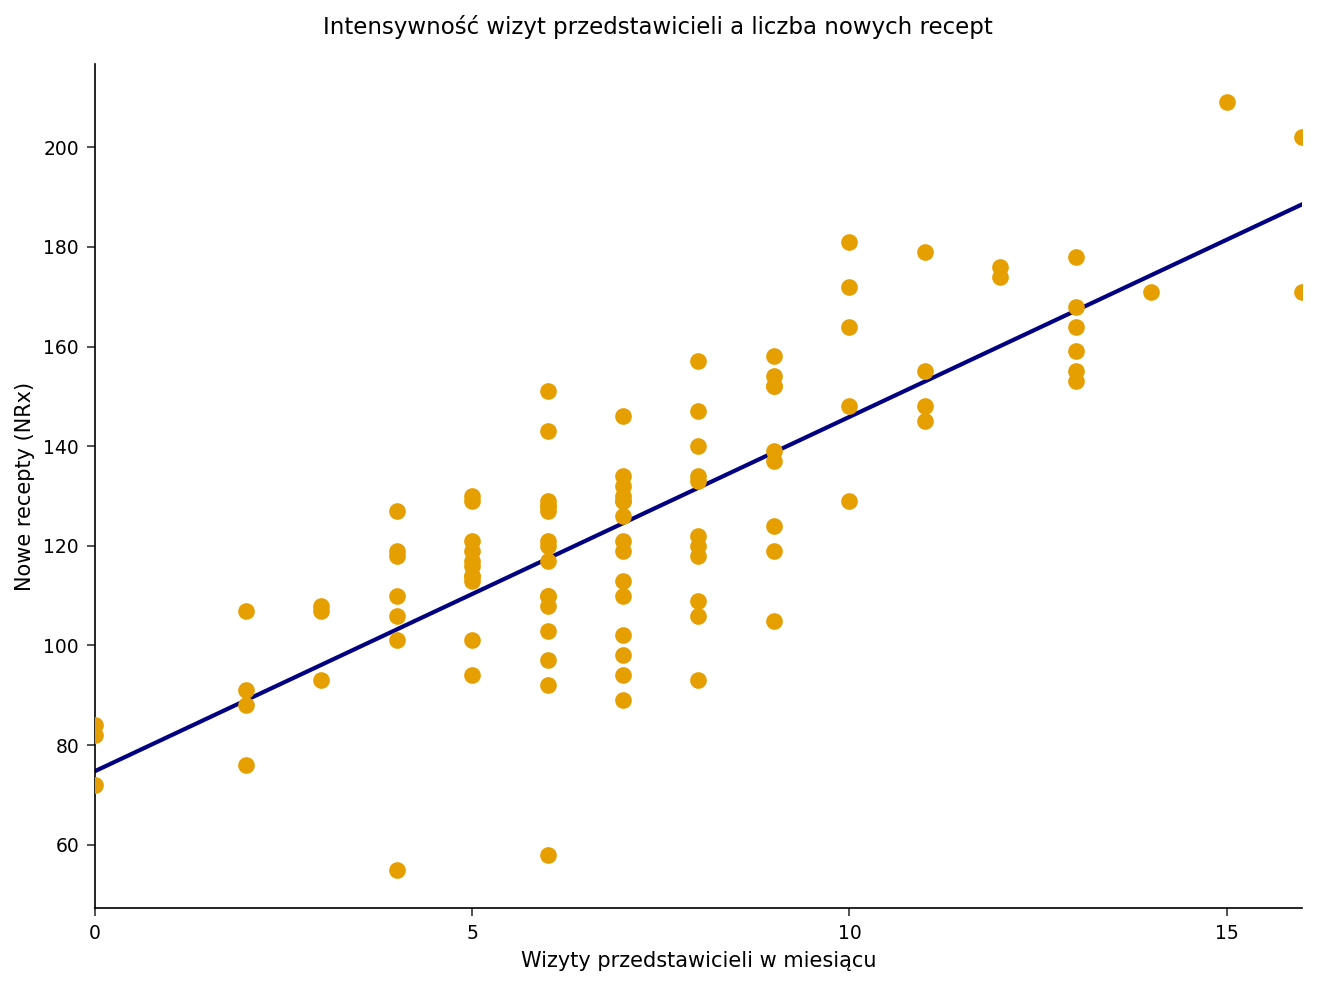

In [3]:
/* --------------------------------------------------------
   Wykres rozrzutu wizyt przedstawicieli vs nowe recepty
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS ETYKIETA='Wizyty przedstawicieli w miesiącu';
    YAXIS ETYKIETA='Nowe recepty (NRx)';
    TYTUŁ 'Intensywność wizyt przedstawicieli a liczba nowych recept';
WYKONAJ;

---

In [4]:
/* --------------------------------------------------------
   Dopasowanie modelu autoregresyjnego z doborem opóźnień BACKSTEP
   NLAG=3 testuje do trzech opóźnień; BACKSTEP automatycznie
   usuwa nieistotne opóźnienia
   -------------------------------------------------------- */
PROCEDURA autoreg DANE=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    WYJŚCIE out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
    TYTUŁ 'Model autoregresyjny liczby nowych recept (NRx)';
WYKONAJ;

                                  Statystyki opisowe: recepty i wizyty przedstawicieli                                  


                     The AUTOREG Procedure

                     Dependent Variable   Nowe recepty (NRx)


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3


NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Przechwycenie oszacowań parametrów do obliczenia ROI
   -------------------------------------------------------- */
ODS WYJŚCIE parameterestimates=work.detail_params;

PROCEDURA autoreg DANE=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
WYKONAJ;

ODS WYJŚCIE CLOSE;

                                  Statystyki opisowe: recepty i wizyty przedstawicieli                                  


                     The AUTOREG Procedure

                     Dependent Variable   Nowe recepty (NRx)


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Obliczenie krańcowego ROI na jedną wizytę przedstawiciela.
   Zbiór ODS ParameterEstimates przechowuje kolumnę Variable
   wielkimi literami, więc filtrujemy po 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROCEDURA DRUKUJ DANE=work.detail_params;
    GDZIE variable = 'DETAIL_VISITS';
    TYTUŁ 'Krańcowy wpływ wizyt przedstawicieli na NRx';
WYKONAJ;

                                      Krańcowy wpływ wizyt przedstawicieli na NRx                                       

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Interpretacja

PROC AUTOREG dopasował szereg recept na podstawie 100 miesięcznych obserwacji. Każda dodatkowa wizyta promocyjna wiąże się z **+2.72 nowej recepty miesięcznie** (oszacowanie 2.7158, t = 7.66, p < 0.0001), a każda jednostka próbek pozostawionych lekarzom dodaje **+1.00 NRx** (oszacowanie 0.9997, t = 14.73), co wskazuje, że próbki wzmacniają, lecz nie zastępują promocji bezpośredniej. Dostęp do listy leków (formulary) wnosi **+24.78 NRx miesięcznie** (t = 13.83), podkreślając dostęp w ramach zarządzanej opieki (managed care) jako warunek wstępny skuteczności wizyt promocyjnych, podczas gdy udział konkurencji wywiera silny negatywny efekt na poziomie **-42.26 NRx na jednostkę udziału** (t = -6.96), sygnalizując terytoria pod presją konkurencyjną, gdzie same wizyty promocyjne mogą okazać się niewystarczające. Wyraz wolny (intercept) wynosi 69.56.

Przy NLAG=3 i BACKSTEP model zachował **dwa opóźnienia autoregresyjne**: opóźnienie 1 (współczynnik -0.3700, t = -3.78) oraz opóźnienie 2 (współczynnik -0.1995, t = -2.04); opóźnienie 3 zostało usunięte jako nieistotne. Statystyka Durbina-Watsona po korekcie wynosi **1.01**, co nadal znajduje się znacznie poniżej 2 i sygnalizuje resztową dodatnią autokorelację, zatem struktura AR(2) obejmuje część, lecz nie całość zależności szeregowej w tym szeregu. Statystyki dopasowania: SSE = 5527.65, MSE = 58.19, AIC = 701.34, SBC = 722.19, logarytm wiarygodności = -342.67.

Planowanie sił terenowych powinno koncentrować się na terytoriach z korzystnym dostępem do listy leków (formulary) i umiarkowanym udziałem konkurencji, gdzie krańcowy zwrot z każdej wizyty promocyjnej jest najwyższy.

---

In [7]:
/* --------------------------------------------------------
   Eksport wartości dopasowanych i parametrów do pulpitu
   planowania sił terenowych
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>